# **Prediksi Churn Pelanggan**

# Week 3 - Modeling Dengan Preprocessing

**Dataset:** Sales and Marketing Customer Dataset  
**Unit Kompetensi:** Membangun model dan menghasilkan prediksi dengan data yang bersih.


## Load Data & Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/bengkod-churn/dataset/Sales - Marketing customer dataset.csv')
print(f'Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.')

Mounted at /content/drive
Dataset berhasil dimuat dengan 15000 baris dan 30 kolom.


## 1. Melakukan preprocessing data

### Penanganan Missing Value

In [ ]:
# Penanganan Missing Value Berdasarkan Distribusi
# Modus untuk kategorikal
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# Median untuk numerik yang memiliki outlier/skewed
df['age'] = df['age'].fillna(df['age'].median())
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].median())
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

print('Missing values ditangani dengan Median (numerik) dan Modus (kategorikal).')

Missing values ditangani dengan Median (numerik) dan Modus (kategorikal).


### Penanganan Duplikasi Data

In [ ]:
print('--- Cek Duplikasi Data ---')
initial_rows = df.shape[0]
duplicated_rows = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicated_rows}')

if duplicated_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f'Jumlah baris setelah menghapus duplikasi: {df.shape[0]}')
    print('Duplikasi data berhasil ditangani.')
else:
    print('Tidak ditemukan duplikasi data.')

--- Cek Duplikasi Data ---
Jumlah baris duplikat: 0
Tidak ditemukan duplikasi data.


### Penanganan Outliers

In [ ]:
print('--- Cek dan Penanganan Outliers ---')

# Memilih kolom numerik untuk deteksi outlier
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Kolom yang sudah ditangani missing value sebelumnya dan relevan untuk outlier
# 'coupon_code' dikecualikan karena penanganan missing valuenya berbeda/non-numerik
relevant_numeric_cols = ['age', 'total_spent', 'satisfaction_score']

for col in relevant_numeric_cols:
    print(f'\nProcessing column: {col}')
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f'Jumlah outliers di kolom {col}: {outliers_count}')

    if outliers_count > 0:
        # Capping outliers (mengganti nilai outlier dengan batas IQR terdekat)
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        print(f'Outliers di kolom {col} telah ditangani dengan capping.')
    else:
        print(f'Tidak ada outliers signifikan di kolom {col}.')

print('\nPenanganan outliers selesai.')

--- Cek dan Penanganan Outliers ---

Processing column: age
Jumlah outliers di kolom age: 218
Outliers di kolom age telah ditangani dengan capping.

Processing column: total_spent
Jumlah outliers di kolom total_spent: 119
Outliers di kolom total_spent telah ditangani dengan capping.

Processing column: satisfaction_score
Jumlah outliers di kolom satisfaction_score: 753
Outliers di kolom satisfaction_score telah ditangani dengan capping.

Penanganan outliers selesai.


### **Analisis dan Penanganan Outliers**

Berdasarkan hasil deteksi di atas, terdapat outlier pada kolom berikut:
1.  **age** (218 outlier)
2.  **total_spent** (119 outlier)
3.  **satisfaction_score** (753 outlier)

**Alasan Penanganan dengan Capping:**
Outlier pada fitur-fitur ini ditangani menggunakan metode **Capping (Winsorizing)** pada batas IQR. Alasan logisnya adalah:
*   **Menjaga Ukuran Data:** Kita tidak menghapus baris agar tidak kehilangan informasi penting dari fitur lain pada pelanggan tersebut.
*   **Mengurangi Bias:** Dengan membatasi nilai ekstrim ke batas atas/bawah yang wajar, kita mencegah model (terutama model sensitif seperti Logistic Regression) memberikan bobot yang terlalu besar pada nilai ekstrim, sehingga hasil prediksi menjadi lebih stabil dan generalis.

### Encoding untuk fitur kategorikal

In [ ]:
# Feature Engineering untuk Tanggal & Encoding
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# Ubah tanggal menjadi fitur numerik (jumlah hari)
ref_date = df['last_purchase_date'].max()
df['days_since_signup'] = (ref_date - df['signup_date']).dt.days
df['days_since_last_purchase'] = (ref_date - df['last_purchase_date']).dt.days

# Identifikasi kolom untuk One-Hot Encoding (hanya yang kardinalitas rendah)
# Kita kecualikan kolom ID, tanggal mentah, dan kolom yang terlalu unik
ignore_cols = ['customer_id', 'coupon_code', 'signup_date', 'last_purchase_date', 'country', 'city']
cat_to_encode = [c for c in df.select_dtypes(include='object').columns if c not in ignore_cols]

df_encoded = pd.get_dummies(df.drop(columns=['signup_date', 'last_purchase_date']),
                            columns=cat_to_encode, drop_first=True, dtype=int)

print(f'Strategi encoding selesai. Fitur baru: {df_encoded.shape[1]} kolom.')
print(df_encoded[['days_since_signup', 'days_since_last_purchase']].head())

Strategi encoding selesai. Fitur baru: 38 kolom.
   days_since_signup  days_since_last_purchase
0               1035                        69
1                267                       307
2                565                       316
3                407                       660
4                598                       337


### Analisis Mendalam: Distribusi, Outlier, dan Kardinalitas

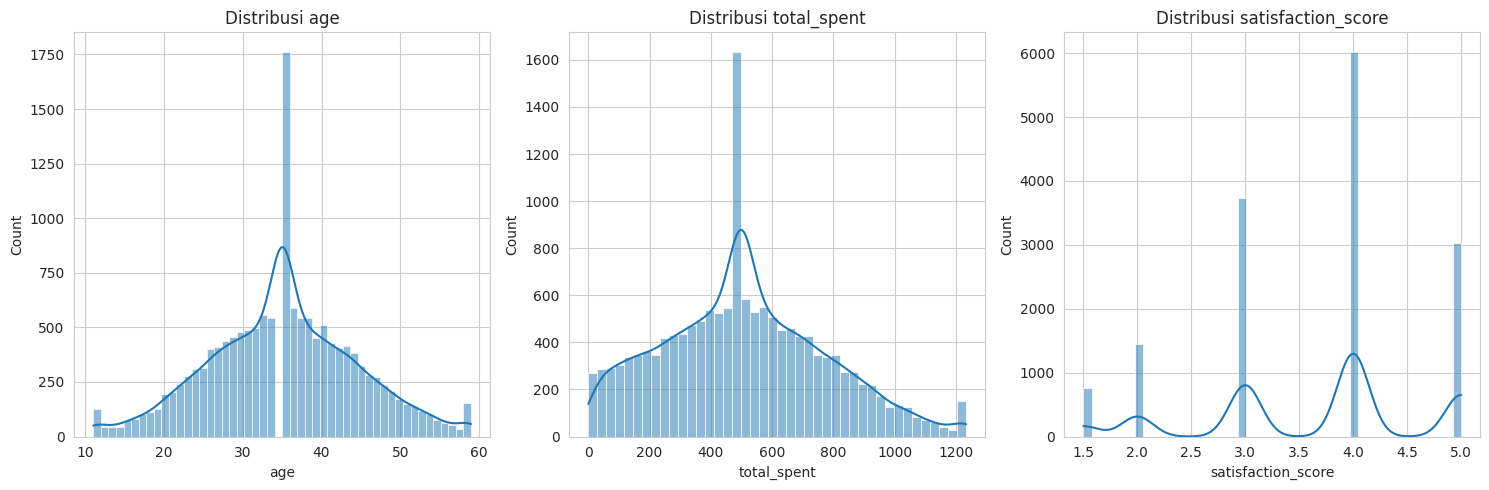

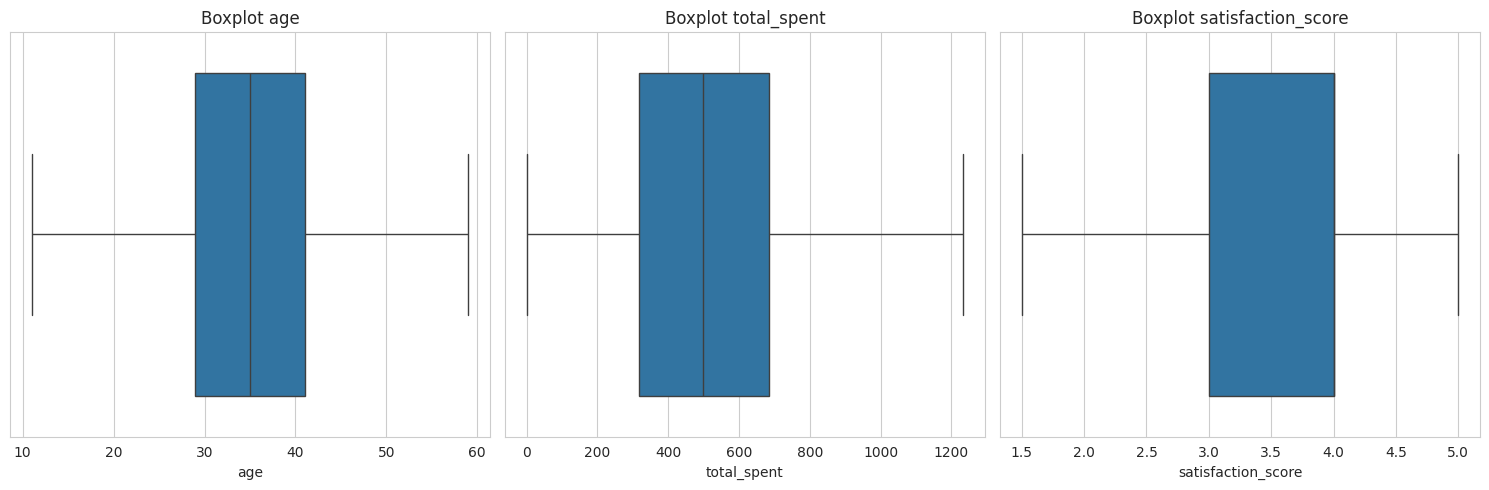

In [ ]:
# 1. Cek Distribusi dan Outlier secara Visual
cols_to_viz = ['age', 'total_spent', 'satisfaction_score']
plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_to_viz, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_viz, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

### Cek Nilai Unik (Kardinalitas) untuk Strategi Encoding
Jika nilai unik terlalu banyak (seperti `signup_date`), One-Hot Encoding akan menghasilkan ribuan kolom baru yang membuat model tidak efisien.

In [ ]:
# 2. Cek Kardinalitas Kolom Kategorikal
cat_features = df.select_dtypes(include=['object']).columns
for col in cat_features:
    print(f'{col}: {df[col].nunique()} nilai unik')

# Saran: Kolom tanggal sebaiknya diekstrak fiturnya (bulan/tahun) daripada langsung di-encode.
# Kolom country/city jika terlalu banyak bisa menggunakan Label Encoding atau Target Encoding.

gender: 3 nilai unik
country: 5 nilai unik
city: 7 nilai unik
acquisition_channel: 5 nilai unik
device_type: 3 nilai unik
subscription_type: 2 nilai unik
coupon_code: 3 nilai unik
payment_method: 5 nilai unik


Pada proses encoding, beberapa kolom tidak ikut diubah ke bentuk numerik, diantaranya:
1. Kolom **customer_id** tidak digunakan karena hanya berisi ID unik pelanggan dan tidak memberikan informasi yang dapat membantu model dalam membuat prediksi.
2. Kolom **coupon_code** juga dikecualikan karena memiliki banyak data yang kosong (missing values) dan dianggap kurang relevan untuk analisis.
3. Kolom **country** dan **city** tidak di-encode karena memiliki terlalu banyak kategori yang berbeda, sehingga dapat membuat data menjadi lebih kompleks.
4. Kolom **membership_level** meskipun sebenarnya memiliki tingkatan tertentu, pada tahap ini kolom tersebut diperlakukan sebagai kategori biasa agar proses preprocessing lebih sederhana dan mudah dilakukan.

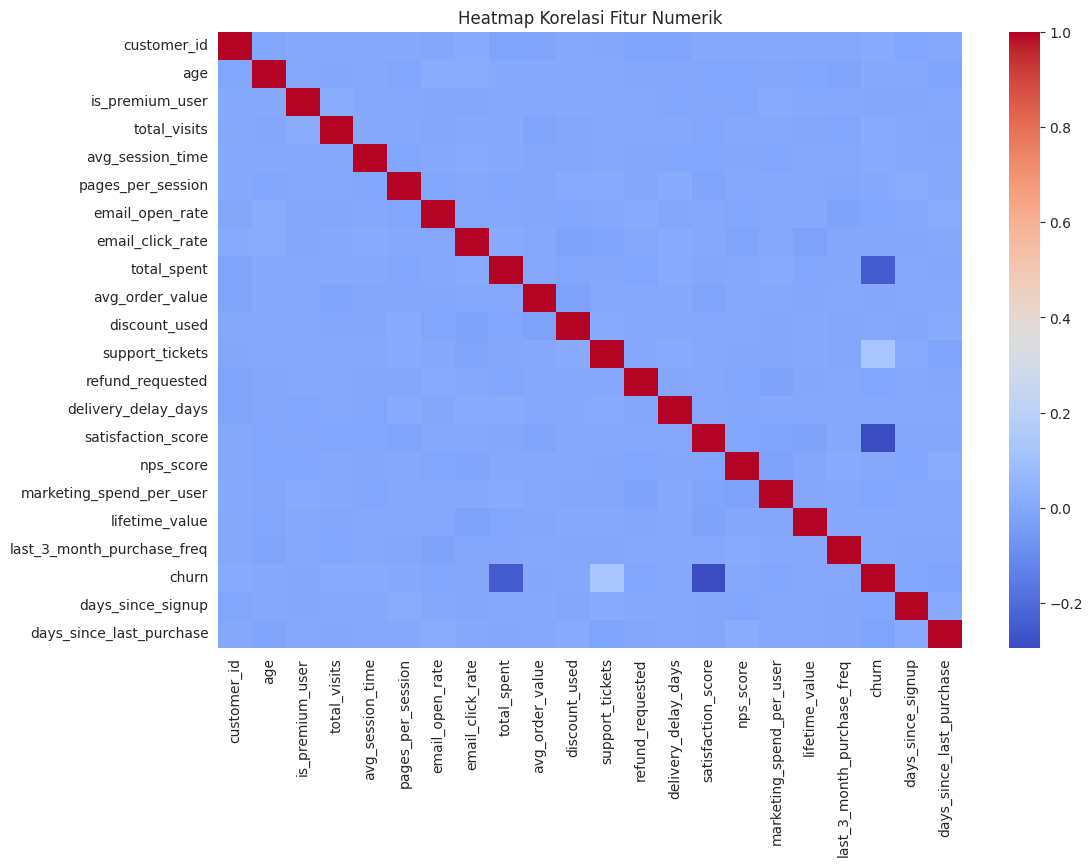

In [ ]:
# Visualisasi Korelasi
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

### Scaling fitur jika diperlukan. Scaling dilakukan setelah data splitting.

In [ ]:
# Memisahkan fitur (X) dan target (y)
# 'churn' adalah target variabel kita
# 'customer_id' dan 'coupon_code' (jika masih ada dan belum dihapus/diencode) tidak digunakan sebagai fitur
# Pastikan 'df_encoded' sudah tersedia dari langkah encoding sebelumnya

X = df_encoded.drop(columns=['churn', 'customer_id', 'coupon_code'])
y = df_encoded['churn']

print(f'Fitur (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')

# Membagi data menjadi training dan testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print('\n--- Feature Scaling ---')

# Identifikasi kolom numerik yang perlu di-scaling
# Exclude biner (0/1) dari one-hot encoding karena tidak perlu di-scale
numerical_cols_to_scale = X_train.select_dtypes(include=np.number).columns.tolist()

# Kolom yang mungkin biner setelah one-hot encoding, tidak perlu di-scale lagi.
# Kita akan menghapus kolom-kolom yang kemungkinan merupakan hasil one-hot encoding
# dari daftar kolom yang akan di-scale.
# Asumsi kolom one-hot encoding dimulai dengan nama kolom asli diikuti underscore.

# Contoh: Identifikasi kolom yang bukan one-hot-encoded dengan melihat apakah nilainya hanya 0 dan 1
# Atau dengan mengecualikan kolom dari list `cols_to_encode` yang sudah di-get_dummies

# Lebih aman, kita ambil kolom numerik asli dari df sebelum encoding,
# kemudian filter yang masih ada di X_train (setelah drop customer_id, churn, coupon_code)
original_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'customer_id' and 'churn' from this list, as they are handled
if 'customer_id' in original_numerical_cols: original_numerical_cols.remove('customer_id')
if 'churn' in original_numerical_cols: original_numerical_cols.remove('churn')

# Filter out 'coupon_code' if it was originally numerical (unlikely but safe check)
if 'coupon_code' in original_numerical_cols: original_numerical_cols.remove('coupon_code')

# Kolom yang perlu di-scale adalah kolom numerik asli yang bukan biner (0/1)
# dan bukan merupakan hasil dari one-hot encoding atau ID
features_to_scale = [col for col in original_numerical_cols if col in X_train.columns and
                     not (X_train[col].nunique() == 2 and X_train[col].min() == 0 and X_train[col].max() == 1)]

# Manual check for 'is_premium_user' which is binary but might be in original_numerical_cols
if 'is_premium_user' in features_to_scale:
    features_to_scale.remove('is_premium_user')

print(f'Kolom yang akan di-scale: {features_to_scale}')

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit scaler hanya pada data training dan transformasikan keduanya
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

print('\nData training setelah scaling:')
print(X_train[features_to_scale].head())
print('\nData testing setelah scaling:')
print(X_test[features_to_scale].head())

print('\nFeature scaling selesai.')

Fitur (X) shape: (15000, 35)
Target (y) shape: (15000,)
X_train shape: (12000, 35)
X_test shape: (3000, 35)
y_train shape: (12000,)
y_test shape: (3000,)

--- Feature Scaling ---
Kolom yang akan di-scale: ['age', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'support_tickets', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'days_since_signup', 'days_since_last_purchase']

Data training setelah scaling:
            age  total_visits  avg_session_time  pages_per_session  \
8722  -0.125352     -1.800890          0.658691          -1.160708   
12778 -0.019525     -0.257490          0.119994           0.829867   
11229 -0.125352     -1.029190          0.363930          -0.708615   
4671   0.721264     -1.029190         -0.357159          -0.061085   
4247   0.615437     -0.514724         -0.341088          -1.119811   

  

### Penghapusan fitur yang tidak relevan

In [ ]:
# Menghapus fitur 'country' dan 'city' dari X_train dan X_test
# Karena kolom ini tidak di-encode karena kardinalitas tinggi
# dan tidak relevan untuk model tanpa preprocessing lebih lanjut
print("--- Menghapus fitur 'country' dan 'city' ---")
if 'country' in X_train.columns:
    X_train = X_train.drop(columns=['country'])
    X_test = X_test.drop(columns=['country'])
    print("Kolom 'country' berhasil dihapus dari X_train dan X_test.")
else:
    print("Kolom 'country' tidak ditemukan di X_train atau sudah dihapus.")

if 'city' in X_train.columns:
    X_train = X_train.drop(columns=['city'])
    X_test = X_test.drop(columns=['city'])
    print("Kolom 'city' berhasil dihapus dari X_train dan X_test.")
else:
    print("Kolom 'city' tidak ditemukan di X_train atau sudah dihapus.")

print(f'\nShape X_train setelah penghapusan: {X_train.shape}')
print(f'Shape X_test setelah penghapusan: {X_test.shape}')

--- Menghapus fitur 'country' dan 'city' ---
Kolom 'country' berhasil dihapus dari X_train dan X_test.
Kolom 'city' berhasil dihapus dari X_train dan X_test.

Shape X_train setelah penghapusan: (12000, 33)
Shape X_test setelah penghapusan: (3000, 33)


## 2. Penetapan fitur prediktor (X) dan variabel target (y) setelah preprocessing

In [ ]:
# Menetapkan kembali fitur prediktor (X) dan variabel target (y) setelah seluruh tahap preprocessing
# Ini mencakup penghapusan 'customer_id', 'coupon_code', 'country', dan 'city'

X = df_encoded.drop(columns=['churn', 'customer_id', 'coupon_code', 'country', 'city'])
y = df_encoded['churn']

print(f'Fitur (X) setelah preprocessing: {X.shape}')
print(f'Target (y) setelah preprocessing: {y.shape}')

print('\nContoh 5 baris pertama dari X setelah preprocessing:')
print(X.head())
print('\nContoh 5 baris pertama dari y setelah preprocessing:')
print(y.head())

Fitur (X) setelah preprocessing: (15000, 33)
Target (y) setelah preprocessing: (15000,)

Contoh 5 baris pertama dari X setelah preprocessing:
    age  is_premium_user  total_visits  avg_session_time  pages_per_session  \
0  52.0                1             7         13.903745           5.415164   
1  35.0                0            19          5.112528           5.352441   
2  27.0                1            18          9.742749           3.594719   
3  36.0                1            16          9.642654           2.949531   
4  29.0                0            12          7.791291           2.405539   

   email_open_rate  email_click_rate  total_spent  avg_order_value  \
0             0.67              0.26   559.524958        65.246704   
1             0.70              0.37   356.491344        48.473887   
2             0.47              0.44   689.332196        77.815371   
3             0.58              0.37   445.429636        71.712192   
4             0.05              0

## 3. Melakukan train–test split


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Train-test split (proporsi sama dengan direct modeling: 80/20, stratify)
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling DILAKUKAN SETELAH split (fit hanya pada data latih -> cegah data leakage)
# Hanya kolom numerik kontinu yang di-scale; kolom biner (0/1) hasil one-hot dilewati.
features_to_scale = [c for c in X_train_final.select_dtypes(include=np.number).columns
                     if not (X_train_final[c].nunique() == 2 and
                             X_train_final[c].min() == 0 and X_train_final[c].max() == 1)]

scaler = StandardScaler()
X_train_final[features_to_scale] = scaler.fit_transform(X_train_final[features_to_scale])
X_test_final[features_to_scale]  = scaler.transform(X_test_final[features_to_scale])

print(f'Shape X_train_final: {X_train_final.shape}')
print(f'Shape X_test_final : {X_test_final.shape}')
print(f'Jumlah kolom di-scale: {len(features_to_scale)}')
print('\nTrain-test split + scaling selesai (data siap untuk modeling).')

Shape X_train_final: (12000, 33)
Shape X_test_final : (3000, 33)
Jumlah kolom di-scale: 17

Train-test split + scaling selesai (data siap untuk modeling).


## 4. Melatih ketiga model menggunakan data hasil preprocessing (tanpa tuning)

Tiga model yang dipakai **konsisten dengan tahap Direct Modeling**: satu model konvensional (**Logistic Regression**), satu ensemble bagging (**Random Forest**), dan satu gabungan model konvensional (**VotingClassifier: LR + SVM + KNN**). Model dilatih pada data yang sudah di-scale.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Tiga model (sama kategori dengan Direct Modeling)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'VotingClassifier (LR+SVM+KNN)': VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('svm', SVC(probability=True, random_state=42)),
            ('knn', KNeighborsClassifier())
        ], voting='soft'),
}

results = {}
print('--- Melatih dan Mengevaluasi Model (data hasil preprocessing) ---')
for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    acc = accuracy_score(y_test_final, model.predict(X_test_final))
    results[name] = acc
    print(f'{name} - Akurasi: {acc:.4f}')

print('\nSemua model berhasil dilatih.')

--- Melatih dan Mengevaluasi Model (data hasil preprocessing) ---
Logistic Regression - Akurasi: 0.8457
Random Forest - Akurasi: 0.8547
VotingClassifier (LR+SVM+KNN) - Akurasi: 0.8473

Semua model berhasil dilatih.


## 5. Evaluasi performa model

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)
import pandas as pd

print('--- Ringkasan Metrik Evaluasi (Week 3) ---')
rows = []
for name, model in models.items():
    yp = model.predict(X_test_final)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_final, yp),
        'Precision': precision_score(y_test_final, yp, zero_division=0),
        'Recall': recall_score(y_test_final, yp, zero_division=0),
        'F1-Score': f1_score(y_test_final, yp, zero_division=0),
    })
metrics_df = pd.DataFrame(rows).set_index('Model').round(4)
print(metrics_df.to_string())

--- Ringkasan Metrik Evaluasi (Week 3) ---
                               Accuracy  Precision  Recall  F1-Score
Model                                                               
Logistic Regression              0.8457     0.4898  0.1565    0.2372
Random Forest                    0.8547     0.5513  0.2804    0.3718
VotingClassifier (LR+SVM+KNN)    0.8473     0.5109  0.1022    0.1703


### Confusion Matrix - Logistic Regression

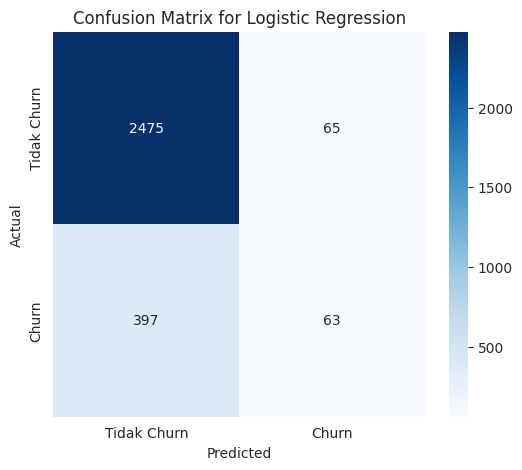

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Memprediksi pada data testing final untuk Logistic Regression
y_pred_lr = models['Logistic Regression'].predict(X_test_final)

# Menampilkan Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test_final, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix - VotingClassifier (LR+SVM+KNN)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_vc = models['VotingClassifier (LR+SVM+KNN)'].predict(X_test_final)
cm_vc = confusion_matrix(y_test_final, y_pred_vc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_vc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix - VotingClassifier (LR+SVM+KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix - Random Forest Classifier

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_rf = models['Random Forest'].predict(X_test_final)
cm_rf = confusion_matrix(y_test_final, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Week 4 - Hyperparameter Tuning dan Feature Selection

**Dataset:** Sales and Marketing Customer Dataset  
**Unit Kompetensi:** Mengoptimalkan kinerja model melalui hyperparameter tuning.



### 1. Analisis Feature Importance
Sebelum melakukan Hyperparameter Tuning, kita akan mengevaluasi tingkat kepentingan (importance) dari masing-masing fitur menggunakan model Random Forest. Fitur yang memiliki nilai kontribusi sangat rendah dapat dipertimbangkan untuk dieliminasi agar mempercepat komputasi dan mengurangi noise pada model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Gunakan data hasil preprocessing yang sama dengan Week 3
# (X_train_final, X_test_final, y_train_final, y_test_final sudah di-scale)
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_train_final, y_train_final)

importances = rf_selector.feature_importances_
feature_imp_df = pd.DataFrame({'Fitur': X_train_final.columns, 'Importance': importances}
                             ).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=feature_imp_df.head(15))
plt.title('Top 15 Fitur Paling Berpengaruh (Feature Importance)')
plt.tight_layout()
plt.show()

### 2 & 3. Menyusun Parameter Grid dan Eksekusi Hyperparameter Tuning

Tuning dilakukan untuk **ketiga model** yang konsisten dengan skenario sebelumnya: **Random Forest**, **Logistic Regression**, dan **VotingClassifier (LR+SVM+KNN)**. Metode: `RandomizedSearchCV` dengan scoring `f1` (karena data imbalance). Semua dilatih pada data hasil preprocessing yang sudah di-scale (`X_train_final`).

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- TUNING 1: RANDOM FOREST (bagging) ---
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30],
     'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    n_iter=10, cv=5, random_state=42, n_jobs=-1, scoring='f1')
rf_random.fit(X_train_final, y_train_final)

# --- TUNING 2: LOGISTIC REGRESSION (konvensional) ---
lr_random = RandomizedSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2']},
    n_iter=5, cv=5, random_state=42, n_jobs=-1, scoring='f1')
lr_random.fit(X_train_final, y_train_final)

# --- TUNING 3: VOTINGCLASSIFIER (gabungan LR+SVM+KNN) ---
# Tuning hyperparameter masing-masing estimator di dalam ensemble.
vc_base = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier())], voting='soft')
vc_random = RandomizedSearchCV(
    vc_base,
    {'lr__C': [0.1, 1, 10], 'svm__C': [0.1, 1, 10], 'knn__n_neighbors': [3, 5, 7]},
    n_iter=8, cv=3, random_state=42, n_jobs=-1, scoring='f1')
vc_random.fit(X_train_final, y_train_final)

print('Proses Hyperparameter Tuning untuk 3 model selesai.')

Proses Hyperparameter Tuning untuk 3 model selesai.


### 4 & 5. Best Parameters, Best Estimator, dan Melatih Ulang

Menampilkan kombinasi parameter terbaik untuk masing-masing model. `best_estimator_` dari `RandomizedSearchCV` otomatis sudah dilatih ulang (refit) pada seluruh data latih dengan konfigurasi optimal.

In [ ]:
print('=== BEST PARAMETERS RANDOM FOREST ===')
print(rf_random.best_params_)
best_rf_model = rf_random.best_estimator_

print('\n=== BEST PARAMETERS LOGISTIC REGRESSION ===')
print(lr_random.best_params_)
best_lr_model = lr_random.best_estimator_

print('\n=== BEST PARAMETERS VOTINGCLASSIFIER (LR+SVM+KNN) ===')
print(vc_random.best_params_)
best_vc_model = vc_random.best_estimator_

=== BEST PARAMETERS RANDOM FOREST ===
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

=== BEST PARAMETERS LOGISTIC REGRESSION ===
{'penalty': 'l2', 'C': 1}

=== BEST PARAMETERS VOTINGCLASSIFIER (LR+SVM+KNN) ===
{'svm__C': 0.1, 'lr__C': 0.1, 'knn__n_neighbors': 3}


### 6. Evaluasi Performa Model Hasil Tuning

Evaluasi ketiga model optimal memakai accuracy, precision, recall, F1-score, dan confusion matrix.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tuned_models = {
    'Logistic Regression': best_lr_model,
    'Random Forest': best_rf_model,
    'VotingClassifier (LR+SVM+KNN)': best_vc_model,
}

print('--- Ringkasan Metrik Model Hasil Tuning ---')
rows = []
for name, mdl in tuned_models.items():
    yp = mdl.predict(X_test_final)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_final, yp),
        'Precision': precision_score(y_test_final, yp, zero_division=0),
        'Recall': recall_score(y_test_final, yp, zero_division=0),
        'F1-Score': f1_score(y_test_final, yp, zero_division=0),
    })
print(pd.DataFrame(rows).set_index('Model').round(4).to_string())

# Confusion matrix ketiga model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, mdl) in zip(axes, tuned_models.items()):
    cm = confusion_matrix(y_test_final, mdl.predict(X_test_final))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix - Model Hasil Tuning', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- Ringkasan Metrik Model Hasil Tuning ---
                               Accuracy  Precision  Recall  F1-Score
Model                                                               
Logistic Regression              0.8457     0.4898  0.1565    0.2372
Random Forest                    0.8517     0.5285  0.3022    0.3845
VotingClassifier (LR+SVM+KNN)    0.8473     0.5083  0.1326    0.2103


---
## Kesimpulan: 9 Model (3 Kategori x 3 Skenario)

Ringkasan F1-Score kelas Churn pada seluruh skenario:

| Model | Direct (W2) | Preprocessing (W3) | Tuning (W4) |
|---|---|---|---|
| Logistic Regression | 0.2341 | 0.2372 | 0.2372 |
| Random Forest | 0.4364 | 0.3718 | **0.3845** |
| VotingClassifier (LR+SVM+KNN) | 0.0129 | 0.1703 | 0.2103 |

**Model terbaik: Random Forest** (F1 tertinggi & paling stabil di semua skenario). Model inilah yang dipakai untuk deployment (Week 5).

Catatan: Voting & Logistic Regression membaik setelah scaling diterapkan (W3/W4) dibanding Direct Modeling, karena SVM/KNN/LR sensitif terhadap skala fitur.